正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
正在计算 10 日线性回归斜率因子 (这可能需要一两分钟)...
开始按日盯盘执行【线性回归趋势 + 小市值低价】调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\回测excel\线性回归趋势_小市值低价_明细.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 114,369.02 元
📈 策略总收益率: 128.74%


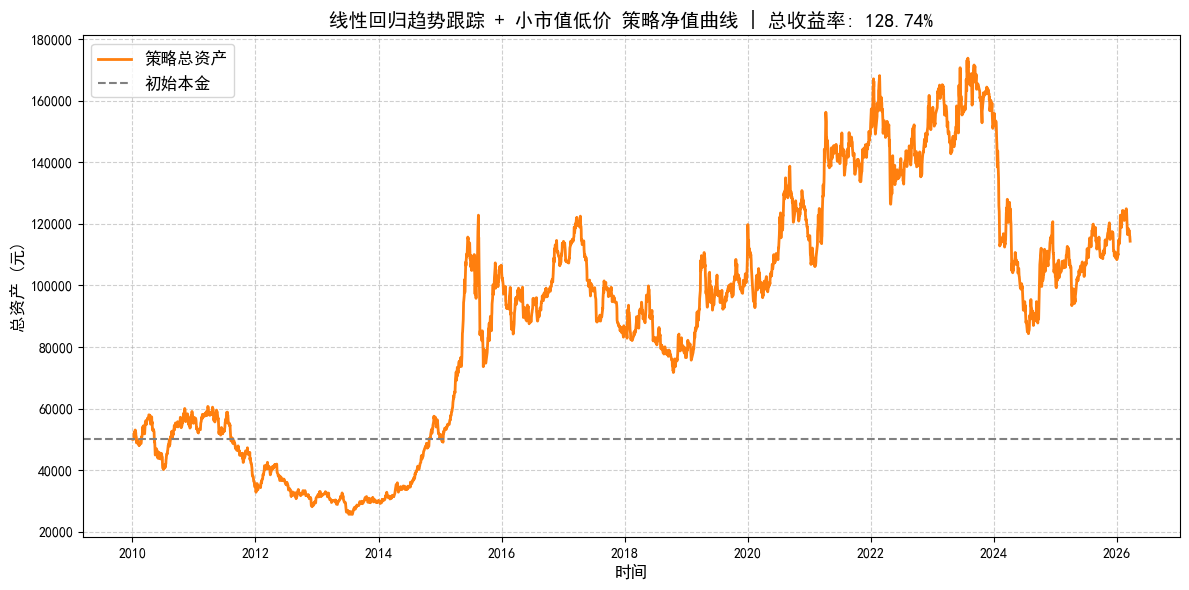

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\线性回归趋势_小市值低价_明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

# 趋势判定斜率阈值 (10日平均每天涨跌幅超过 0.5% 视为有明显趋势)
SLOPE_THRESHOLD = 0.5

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

df.sort_values(by=['code', 'date'], inplace=True)

# ==========================================
# 第二步：计算 10 日线性回归斜率与趋势打标
# ==========================================
print("正在计算 10 日线性回归斜率因子 (这可能需要一两分钟)...")

# 线性回归斜率推导优化：由于 x 是固定的 0~9，我们可以直接用矩阵点乘加速计算
# 权重 = x - mean(x) = np.arange(10) - 4.5
weights = np.arange(10) - 4.5
# 方差 sum((x - mean(x))^2) = 82.5

def calc_slope_pct(y):
    # 计算斜率，并除以这10天的均价，得到“斜率百分比”
    slope = np.dot(weights, y) / 82.5
    return (slope / np.mean(y)) * 100

# 使用 rolling.apply 高效计算斜率百分比
df['slope_pct'] = df.groupby('code')['close'].transform(
    lambda x: x.rolling(10).apply(calc_slope_pct, raw=True)
)

# 核心：根据斜率进行趋势打标
df['trend'] = 'sideways' # 默认为横盘
df.loc[df['slope_pct'] > SLOPE_THRESHOLD, 'trend'] = 'uptrend'    # 上升通道
df.loc[df['slope_pct'] < -SLOPE_THRESHOLD, 'trend'] = 'downtrend' # 下降通道

# ==========================================
# 提取交易日历 (按日循环，周五补仓)
# ==========================================
df.sort_values(by=['date', 'code'], inplace=True)

# 提取每周的最后一个交易日作为“买入补仓日”
df['year_week'] = df['date'].dt.to_period('W')
trade_dates_list = df.groupby('year_week')['date'].max().sort_values().tolist()
# 转为 set，查找速度提升 O(1)
trade_dates_set = set(trade_dates_list)

# 提取所有交易日用于“每日盯盘卖出”
all_dates = np.sort(df['date'].unique())

# ==========================================
# 第三步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第四步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按日盯盘执行【线性回归趋势 + 小市值低价】调仓模拟...")

# 将大表按日期分组，极大加速每天的截面查询
grouped_by_date = dict(tuple(df.groupby('date')))

for date in all_dates:
    daily_data = grouped_by_date[date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 每日盯盘：卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        # --- 检测是否退市 ---
        if code not in daily_data.index:
            lost_vol = account.positions[code]['volume']
            last_price = account.positions[code]['price']
            loss_amount = lost_vol * last_price

            del account.positions[code]
            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol, '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': f'数据缺失/退市，市值计提全额亏损 {round(loss_amount, 2)}元'
            })
            continue

        # 提取该股今天的趋势状态
        pos = account.positions[code]
        trend = daily_data.loc[code, 'trend']
        is_trading = status_dict.get(code, 0) == 1
        pct_chg = pct_chg_dict.get(code, 0)

        # 核心逻辑：记录该股是否已经走出了上升通道
        if trend == 'uptrend':
            pos['reached_uptrend'] = True

        execute_sell = False
        sell_memo = ''

        # 卖出条件判断
        if trend == 'downtrend':
            execute_sell = True
            sell_memo = '进入下降通道止损'
        elif trend == 'sideways' and pos.get('reached_uptrend', False) == True:
            execute_sell = True
            sell_memo = '上升通道转横盘止盈'

        if execute_sell:
            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = pos['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': sell_memo
                })
            elif not is_trading:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(停牌)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'尝试{sell_memo}，但股票停牌强制保留'
                })
            elif pct_chg <= -9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'尝试{sell_memo}，但跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 每周五收盘：补仓买入逻辑 ----------------
    if date in trade_dates_set:
        current_pos_count = len(account.positions)
        free_slots = max(0, TARGET_STOCK_NUM - current_pos_count)

        if free_slots > 0:
            # 选股条件：正常交易、非ST、PE>0、PB>0、且【处于横盘状态】
            valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                                    (daily_data['isST'] == 0) &
                                    (daily_data['peTTM'] > 0) &
                                    (daily_data['pbMRQ'] > 0) &
                                    (daily_data['trend'] == 'sideways')].copy()

            target_codes = []
            if len(valid_pool) >= 50:
                # 选出市值最小的 50 只
                smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50)
                # 再在这 50 只里选出价格最低的补空位
                target_codes = smallest_50.sort_values(by='close', ascending=True).head(free_slots).index.tolist()

            actual_stocks_to_buy = [c for c in target_codes if c not in account.positions]

            if len(actual_stocks_to_buy) > 0:
                target_cash_per_stock = account.cash / len(actual_stocks_to_buy)

                for code in actual_stocks_to_buy:
                    is_trading = status_dict.get(code, 0) == 1
                    pct_chg = pct_chg_dict.get(code, 0)
                    is_st = st_dict.get(code, 0) == 1

                    if is_trading and not is_st and pct_chg < 9.3:
                        buy_price = current_prices[code]
                        affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                        buy_vol = (affordable_shares // 100) * 100

                        if buy_vol >= 100:
                            fee, amount = calculate_fees('buy', buy_price, buy_vol)
                            if account.cash >= (amount + fee):
                                account.cash -= (amount + fee)
                                # 初始买入时，设定 reached_uptrend 为 False
                                account.positions[code] = {'volume': buy_vol, 'price': buy_price, 'reached_uptrend': False}

                                account.trade_logs.append({
                                    '日期': date, '股票代码': code, '买卖方向': '买入',
                                    '成交价': buy_price, '成交股数': buy_vol,
                                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                                    '备注': '横盘低价补仓'
                                })
                    elif pct_chg >= 9.3:
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                            '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': f'涨幅 {pct_chg:.2f}% 封死涨停'
                        })

# ==========================================
# 第五步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#ff7f0e', linewidth=2, label='策略总资产')
plt.title(f'线性回归趋势跟踪 + 小市值低价 策略净值曲线 | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()